<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 06

## Tree methods

### Are RSS Gain Maximization and Total RSS Minimization equivalent?
Yes, they are completely equivalent.
Proof: Let $T$ be our current partially built tree, and $\mathcal{L}$ be the set of all its current leaf nodes. The Total RSS of the current tree is the sum of the RSS of all its leaves:$$RSS_{total}(T) = \sum_{k \in \mathcal{L}} RSS_k$$Suppose we choose a specific leaf node to act as the $Parent$, and we split it into two new leaves, $Left$ and $Right$. The new tree, $T_{new}$, will have all the same leaves as $T$, except the $Parent$ is removed and replaced by $Left$ and $Right$.The Total RSS of the new tree becomes:$$RSS_{total}(T_{new}) = \left( \sum_{k \in \mathcal{L}, k \neq Parent} RSS_k \right) + RSS_{Left} + RSS_{Right}$$Notice that the sum of the RSS of all untouched leaves can be rewritten in terms of the old tree's Total RSS:$$\sum_{k \in \mathcal{L}, k \neq Parent} RSS_k = RSS_{total}(T) - RSS_{Parent}$$Substitute this back into our $T_{new}$ equation: $$RSS_{total}(T_{new}) = RSS_{total}(T) - RSS_{Parent} + RSS_{Left} + RSS_{Right}$$ $$RSS_{total}(T_{new}) = RSS_{total}(T) - (RSS_{Parent} - (RSS_{Left} + RSS_{Right}))$$The term $(RSS_{Parent} - (RSS_{Left} + RSS_{Right}))$ is exactly the definition of RSS Gain. Because $RSS_{total}(T)$ is a fixed constant before we make the split, minimizing the new Total RSS is mathematically identical to maximizing the RSS Gain.

### Are Local RSS Minimization and RSS Gain Maximization equivalent?
No, they are fundamentally different. Local RSS Minimization strictly looks at $RSS_{Left} + RSS_{Right}$, aiming for the lowest possible post-split error. RSS Gain Maximization looks at the relative improvement, prioritizing splits that drop the error by the largest margin, regardless of where the final error ends up.

Counterexample: Imagine a tree with two candidate leaf nodes we could split: Node A and Node B.Node A has an $RSS_{A}$ of 100. Its best possible split yields a left child with RSS of 40 and a right child with RSS of 40.
- Local RSS sum: 80
- RSS Gain: 100 - 80 = 20

Node B has an $RSS_{B}$ of 10. Its best possible split yields a left child with RSS of 2 and a right child with RSS of 2.
- Local RSS sum: 4
- RSS Gain: 10 - 4 = 6

If we are deciding whether to split Node A or Node B (such as in a best-first tree growth scenario):Local RSS Minimization compares the sums (80 vs 4) and chooses to split Node B, because 4 is smaller. RSS Gain Maximization compares the gain (20 vs 6) and chooses to split Node A, because 20 is larger.This proves they can yield completely different split choices.

### Empirical Verification
To test which algorithm scikit-learn uses, we will construct a dataset identical to our counterexample above. We will use the `max_leaf_nodes` parameter as our pre-pruning regularization.

By setting `max_leaf_nodes=3`, the tree is forced to make exactly two splits.

The first split will divide the root into Node A and Node B.

The second split forces the algorithm to choose between splitting Node A or splitting Node B.

By inspecting the final tree, we will see which criteria scikit-learn utilized.

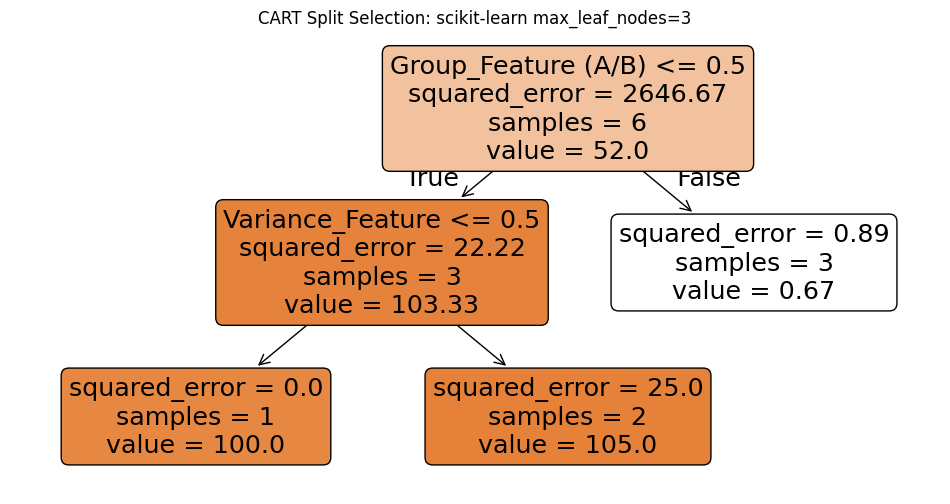

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Create the Artificial Dataset
# Feature 0 separates our data into "Node A" (0) and "Node B" (1).
# Feature 1 is the variance feature that the tree can split on within the nodes.
X = np.array([
    [0, 0], [0, 1], [0, 2],  # Destined for Node A
    [1, 0], [1, 1], [1, 2]   # Destined for Node B
])

# Y is designed so Node A has massive variance (high gain, but high child RSS)
# Node B has tiny variance (low gain, but very low child RSS)
# Node A Mean = 103.33, RSS = 66.67. Best split yields Child RSS sum = 50. Gain = 16.67
# Node B Mean = 0.67,   RSS =  2.67. Best split yields Child RSS sum = 2.  Gain = 0.67
y = np.array([100, 110, 100, 0, 2, 0])

# 2. Train the Model
# We set max_leaf_nodes=3. The root splits once (2 leaves).
# Then it must choose the single best leaf to split again (3 leaves total).
regressor = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
regressor.fit(X, y)

# 3. Visualize the Results
plt.figure(figsize=(12, 6))
plot_tree(
    regressor,
    feature_names=['Group_Feature (A/B)', 'Variance_Feature'],
    filled=True,
    rounded=True,
    precision=2
)
plt.title("CART Split Selection: scikit-learn max_leaf_nodes=3")
plt.show()

Empirical Conclusion: Because the algorithm chose to split the node with the highest variance drop rather than the node that would result in the lowest absolute local error, we can definitively conclude that scikit-learn utilizes RSS Gain Maximization (which is equivalent to Total RSS Minimization), evaluating nodes based on impurity improvement.